In [2]:
import os
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import random
from PIL import Image
import joblib
from pandas.core.frame import DataFrame

# https://www.kaggle.com/code/taranmarley/data-images-cnn

## chuyển đổi ảnh

In [ ]:
df = pd.read_csv('temp/test/udp.csv')
output_dir = "temp/test/udp"

selected_columns = ['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 
                    'Fwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 
                    'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 
                    'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 
                    'Flow IAT Max', 'Flow IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Min', 
                    'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 
                    'Bwd Header Length', 'Bwd Packets/s', 'Packet Length Max', 'FIN Flag Count', 'SYN Flag Count', 
                    'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ratio', 
                    'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 
                    'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate', 'Init Fwd Win Bytes', 'Init Bwd Win Bytes', 
                    'Fwd Seg Size Min', 'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Std', 'Label']

df = df[selected_columns]

X = df.drop("Label", axis=1)
y = df["Label"]

tab2Img = joblib.load("scaler/tab2img.pkl")
test_images = tab2Img.transform(X.to_numpy())

def save_images_by_label(images, ):
    
    img_size=224
    org_size = 7
    scale_factor = img_size // org_size
    count = 1
  
    for img in images:

        img_array = img.reshape(org_size, org_size)
        
        # Normalize to [0, 255] and convert to uint8
        if img_array.max() <= 1.0: 
            img_array = (img_array * 255).astype(np.uint8)
        else:
            img_array = img_array.astype(np.uint8)
        
        zoomed_array = np.kron(img_array, np.ones((scale_factor, scale_factor)))
        scaled_image = zoomed_array.astype(np.uint8)
        img = Image.fromarray(scaled_image, mode='L').convert("RGB")

        # Save image
        img.save(os.path.join(output_dir, f'img_{count}.png'))
        count += 1
        
save_images_by_label(test_images)

## load model

In [3]:
label_map = {'BENIGN': 0, 'Group1' : 1, 'Group2': 2, "Syn": 3 }
num_classes = len(label_map)
print(num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

for name, param in model.named_parameters():
    if 'layer3' in name or 'layer4' in name or 'fc' in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 1024),  # Tăng số neuron
    nn.BatchNorm1d(1024),
    nn.ReLU(),
    nn.Dropout(0.3),  
    nn.Linear(1024, 512),
    nn.GELU(), 
    nn.Linear(512, num_classes)
)
model = model.to(device)
model.load_state_dict(torch.load("temp/models/resnet50_finetuned.pth",  map_location=device))
model.eval()


4


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## dự đoán ảnh trong thư mục

In [ ]:
def predict_image(model, image_path, class_names):
    model.eval()
    image = Image.open(image_path)

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
    
    image = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image)
        _, predicted = torch.max(output, 1)
    print(f'Predicted label: {class_names[predicted.item()]}')

def total_predict_image(model, image_path, class_names):
    model.eval()
    image = Image.open(image_path)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
    image = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image)
        _, predicted = torch.max(output, 1)
    return class_names[predicted.item()]

In [41]:
labels_list = list(label_map.keys())
folder_path = 'temp/test/udp'
images = []

for filename in os.listdir(folder_path):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
        img_path = os.path.join(folder_path, filename)
        # image = Image.open(img_path).convert('RGB')  # chuyển về RGB nếu cần
        images.append(img_path)

# predict_image(model, "data/test/SYN/1.png", list(label_map.keys()))
# predict_image(model, "data/test/haa/rrr.png", list(label_map.keys()))

# predict_image(model, "data/cic_ddos_2019_images/Syn/4343.png", list(label_map.keys()))


name_details_dict = {}
total = 1

for j in images:
    r = total_predict_image(model, f"{j}", labels_list)
    if r in name_details_dict:
        name_details_dict[r] += 1
    else:
        name_details_dict[r] = 1
    
    # total += 1
    # if total == 10:
    #     break

print(name_details_dict)

{'Group2': 944, 'BENIGN': 236}


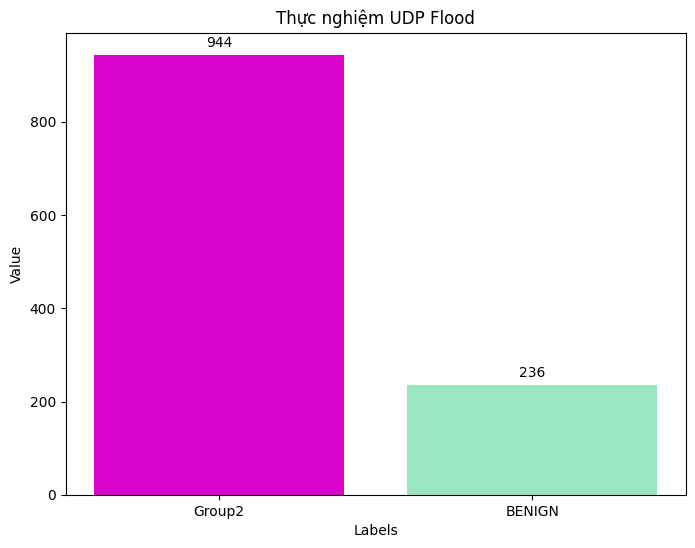

In [ ]:
keys = list(name_details_dict.keys())
values = list(name_details_dict.values())
colors = [f"#{random.randint(0, 0xFFFFFF):06x}" for _ in keys]
plt.figure(figsize=(8, 6))
bars = plt.bar(keys, values, color=colors)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + max(values)*0.01, str(height), 
             ha='center', va='bottom', fontsize=10)

plt.title('Thực nghiệm UDP Flood')
plt.xlabel('Labels')
plt.ylabel('Value')

plt.show()

## test không cần lưu ảnh

In [9]:
tab2Img = joblib.load("scaler/tab2img.pkl")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                            [0.229, 0.224, 0.225])
])

labels_list = list(label_map.keys())

def predict_single_sample(data):

    row = data.to_numpy() 


    img_array = tab2Img.transform(row.reshape(1, -1))[0] 
    org_size = 7
    img_size = 224
    scale_factor = img_size // org_size
    
    # Reshape và chuẩn hóa
    img_array = img_array.reshape(org_size, org_size)
    if img_array.max() <= 1.0:
        img_array = (img_array * 255).astype(np.uint8)
    else:
        img_array = img_array.astype(np.uint8)
    
    zoomed_array = np.kron(img_array, np.ones((scale_factor, scale_factor)))
    scaled_image = zoomed_array.astype(np.uint8)
    img = Image.fromarray(scaled_image, mode='L').convert("RGB")
    input_tensor = transform(img).unsqueeze(0).to(device)  # Thêm batch dimension

    with torch.no_grad():
        output = model(input_tensor)
        predicted_class = torch.argmax(output, dim=1).item()

    return labels_list[predicted_class]

selected_columns2 = ['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 
                    'Fwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 
                    'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 
                    'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 
                    'Flow IAT Max', 'Flow IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Min', 
                    'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 
                    'Bwd Header Length', 'Bwd Packets/s', 'Packet Length Max', 'FIN Flag Count', 'SYN Flag Count', 
                    'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ratio', 
                    'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 
                    'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate', 'Init Fwd Win Bytes', 'Init Bwd Win Bytes', 
                    'Fwd Seg Size Min', 'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Std']



In [24]:
# test 1 dòng

df = pd.read_csv('temp/test/syn.csv') 
df =df[selected_columns2]
first_row = df.iloc[0]
first_row_json = first_row.to_dict()
row_df = DataFrame([first_row_json])

prediction = predict_single_sample(row_df)
print(prediction)

Syn


In [32]:
# test tất cả
df = pd.read_csv('temp/test/benign.csv') 
df =df[selected_columns2]

name_details_dict = {}
total = 1

for index, row in df.iterrows():
    # print(f"Dòng {index}: {row['ten_cot']}")
    r = predict_single_sample(row)
    if r in name_details_dict:
        name_details_dict[r] += 1
    else:
        name_details_dict[r] = 1

    # total += 1
    # if total == 10:
    #     break

print(name_details_dict)

C:\Users\NewTun\AppData\Local\Temp\ipykernel_17996\3971860773.py:27: RuntimeWarning: invalid value encountered in cast
  img_array = img_array.astype(np.uint8)


{'BENIGN': 1163, 'Syn': 16, 'Group2': 10, 'Group1': 1}


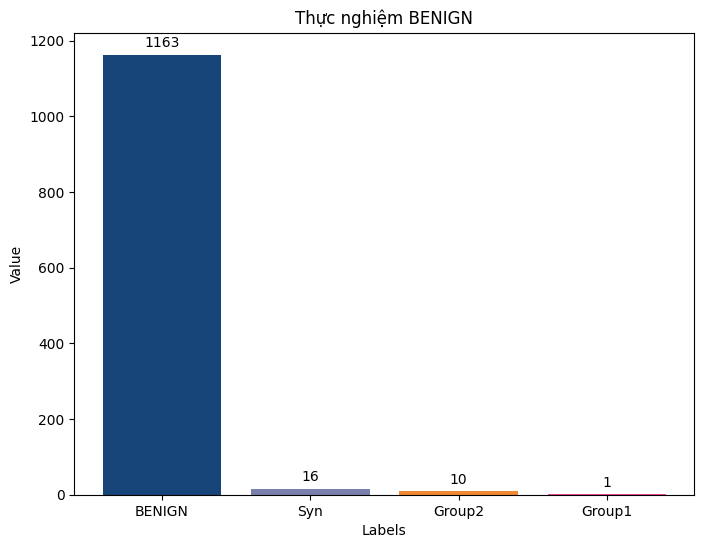

In [34]:
keys = list(name_details_dict.keys())
values = list(name_details_dict.values())
colors = [f"#{random.randint(0, 0xFFFFFF):06x}" for _ in keys]
plt.figure(figsize=(8, 6))
bars = plt.bar(keys, values, color=colors)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + max(values)*0.01, str(height), 
             ha='center', va='bottom', fontsize=10)

plt.title('Thực nghiệm BENIGN')
plt.xlabel('Labels')
plt.ylabel('Value')

plt.show()